# Part 2: QPU vs Simulator — What's the Difference?

In this notebook, we compare results from a **quantum simulator** and a **real quantum processing unit (QPU)**. By running the same circuit on both, we'll observe firsthand how hardware noise affects quantum computation.

### Learning Objectives

1. Understand the fundamental difference between a simulator and a QPU
2. Run a Bell circuit on a local Aer simulator
3. Submit the same circuit to a real QPU via qBraid
4. Compare results and identify the effects of hardware noise
5. Learn about the sources of noise in real quantum hardware

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qbraid.runtime import QbraidProvider
from qbraid.visualization import plot_histogram
import warnings
warnings.filterwarnings("ignore")

## What is a QPU vs a Simulator?

| | **Simulator** | **QPU (Quantum Processing Unit)** |
|---|---|---|
| **What it is** | Classical software that mathematically models quantum behavior | Physical hardware that manipulates real quantum particles |
| **Results** | Perfect, noise-free | Noisy, imperfect |
| **Speed** | Fast for small circuits, exponentially slow for large ones | Constant-time regardless of circuit complexity |
| **Cost** | Low (just compute time) | Higher (hardware access fees) |
| **Use case** | Development, debugging, algorithm design | Validation, benchmarking, real-world experiments |

The key insight: simulators give you the **theoretical answer**, while QPUs give you the **real-world answer** that includes the effects of noise and imperfections.

## Bell Circuit

We'll use the same Bell state circuit from Part 1. On a perfect simulator, we expect only `|00>` and `|11>` outcomes. On real hardware, we'll see additional states (`|01>`, `|10>`) due to noise.

In [2]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

---

## Simulator Run (Qiskit Aer)

First, let's establish our **baseline** by running the circuit on Qiskit's local Aer simulator. This gives us the ideal, noise-free result.

In [12]:
sim = Aer.get_backend("aer_simulator")
sim_counts = sim.run(qc, shots=200).result().get_counts()
print("Simulator counts:", sim_counts)

Simulator counts: {'00': 96, '11': 104}


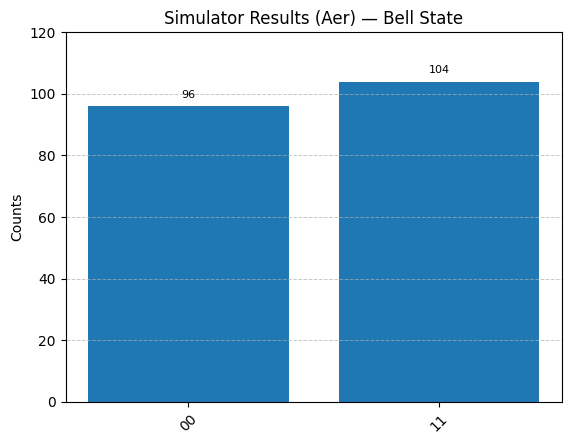

In [13]:
plot_histogram(sim_counts, title="Simulator Results (Aer) — Bell State")

As expected, we see only `|00>` and `|11>` outcomes, each with approximately 50% probability. This is the **ideal** Bell state distribution with zero noise.

---

## QPU Run via qBraid

Now let's run the same circuit on a **real quantum computer**. We'll use qBraid's provider to access a QPU device.

> **Note:** QPU execution incurs real costs and may take longer due to queue times. Check device pricing with `device.metadata()` before submitting.

In [5]:
provider = QbraidProvider()

# List available devices
devices = provider.get_devices()
print("Available devices:")
for d in devices:
    print(f"  {d}")

Available devices:
  QbraidDevice('aws:aqt:qpu:ibex-q1')
  QbraidDevice('aws:quera:qpu:aquila')
  QbraidDevice('aws:ionq:qpu:aria-1')
  QbraidDevice('azure:ionq:qpu:aria-1')
  QbraidDevice('aws:rigetti:qpu:ankaa-3')
  QbraidDevice('aws:aws:sim:tn1')
  QbraidDevice('aws:aws:sim:dm1')
  QbraidDevice('qbraid:nec:sim:vector-annealer')
  QbraidDevice('azure:quantinuum:sim:h2-1e')
  QbraidDevice('azure:rigetti:qpu:ankaa-3')
  QbraidDevice('azure:pasqal:qpu:fresnel')
  QbraidDevice('azure:pasqal:sim:emu-tn')
  QbraidDevice('aws:iqm:qpu:emerald')
  QbraidDevice('azure:ionq:qpu:forte-1')
  QbraidDevice('aws:aws:sim:sv1')
  QbraidDevice('aws:ionq:qpu:forte-1')
  QbraidDevice('aws:ionq:qpu:forte-enterprise-1')
  QbraidDevice('qbraid:qbraid:sim:qir-sv')
  QbraidDevice('aws:iqm:qpu:garnet')
  QbraidDevice('azure:quantinuum:sim:h2-1sc')
  QbraidDevice('azure:rigetti:sim:qvm')
  QbraidDevice('azure:rigetti:qpu:cepheus-1-36q')
  QbraidDevice('azure:ionq:sim:simulator')
  QbraidDevice('azure:ionq:qpu:f

### Selecting a QPU Device

When choosing a QPU, consider:
- **Status** — is the device ONLINE?
- **Number of qubits** — does it support your circuit size?
- **Pricing** — cost per task + cost per shot
- **Queue depth** — how many jobs are waiting?

Use `device.metadata()` to inspect these details before submitting a job.

In [6]:
DEVICE_ID = "aws:iqm:qpu:garnet"
device = provider.get_device(DEVICE_ID)
device.metadata()

{'device_id': 'aws:iqm:qpu:garnet',
 'simulator': False,
 'num_qubits': 20,
 'provider_name': 'iqm',
 'basis_gates': None,
 'name': 'Garnet',
 'pricing': {'perTask': 30.0, 'perShot': 0.145, 'perMinute': 0.0},
 'queue_depth': 0,
 'status': 'ONLINE',
 'paradigm': 'gate_model',
 'runtime_config': {'target_program_type': ['braket', 'qasm3'],
  'conversion_scheme': {'conversion_graph': None,
   'max_path_attempts': 3,
   'max_path_depth': None},
  'options': {'transpile': True,
   'transform': True,
   'validate': 2,
   'prepare': True}}}

> **WARNING: The cell below executes on REAL quantum hardware.** This will incur costs based on the device's pricing (per-task fee + per-shot fee). Review the pricing in the metadata above before running.

In [7]:
# Submit to QPU — review pricing before running!
num_shots = 200
job = device.run(qc, shots=num_shots)
print(job)

<QbraidJob(id:'aws:iqm:qpu:garnet-ae17-qjob-69d89a48830806186373a3e2')>


In [8]:
job.status()

<INITIALIZING: 'job is being initialized'>

In [9]:
qpu_counts = job.result().data.get_counts()
print("QPU Counts:", qpu_counts)

QPU Counts: {'00': 98, '01': 2, '10': 1, '11': 99}


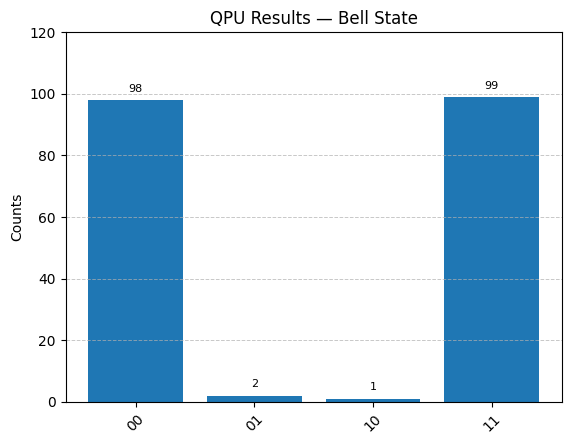

In [10]:
plot_histogram(qpu_counts, title="QPU Results — Bell State")

### Analyzing the QPU Results

Notice the differences from the simulator:

- **Dominant states** (`|00>`, `|11>`) still appear with the highest probability — the quantum hardware *mostly* works correctly.
- **Unexpected states** (`|01>`, `|10>`) appear with small but nonzero probability — these are caused by **hardware noise**.
- The probabilities of `|00>` and `|11>` may not be exactly 50/50 — there can be a **bias** introduced by the hardware.

### Sources of Noise in Quantum Hardware

Real quantum computers are imperfect. The main sources of error include:

| Source | Description |
|---|---|
| **Gate errors** | Each quantum gate has a small probability of applying the wrong operation |
| **Decoherence (T1)** | Qubits lose their energy state over time (amplitude damping) |
| **Dephasing (T2)** | Qubits lose their phase information over time |
| **Readout errors** | The measurement process itself can misidentify `|0>` as `|1>` or vice versa |
| **Crosstalk** | Operations on one qubit unintentionally affect neighboring qubits |

These errors are why we see `|01>` and `|10>` states in our Bell state experiment — they shouldn't exist in an ideal Bell state, but noise introduces them.

---

## Side-by-Side Comparison: Simulator vs QPU

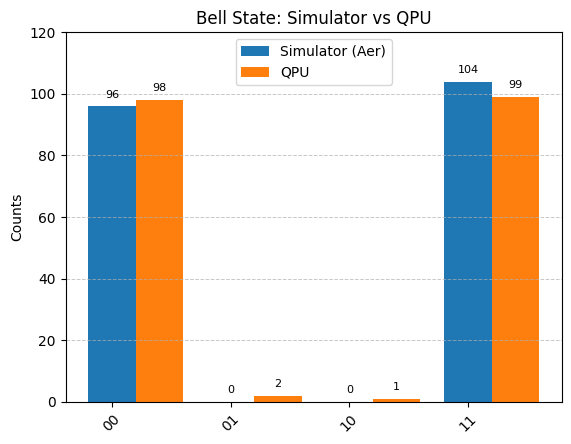

In [14]:
plot_histogram(
    [sim_counts, qpu_counts],
    legend=["Simulator (Aer)", "QPU"],
    title="Bell State: Simulator vs QPU"
)

---

## Key Takeaways

1. **Simulators are ideal** — they give the mathematically exact result with no noise. Use them for development and debugging.

2. **QPUs are noisy** — real hardware introduces errors from gate imperfections, decoherence, and readout mistakes. The correct answer is still the most probable outcome, but "impossible" states also appear.

3. **The same qBraid workflow works for both** — the only difference is the device ID. Switching from a simulator to a QPU is as simple as changing one string.

4. **Error mitigation matters** — as circuits get deeper and use more qubits, noise becomes a bigger problem. Advanced techniques like error mitigation and error correction are active areas of research.

**Next up:** In Part 3, we'll run a more complex algorithm (Bernstein-Vazirani) across *multiple* quantum hardware providers and compare their performance.